# Capítulo 17: Lei de potência

<hr>

Códigos do livro: **Probabilidade e Estatística: Teoria, simulação e Dadados**<br>
Site: https://loja.uiclap.com/titulo/ua158988 <br>
Autor: Francisco A. Rodrigues<br>
https://sites.icmc.usp.br/francisco<br>
Universidade de São Paulo<br>
<hr>

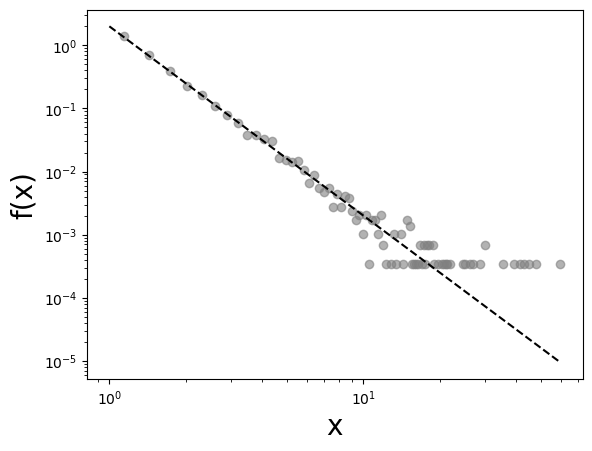

In [1]:
# Pág. 487
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

alpha = 3 # parâmetro do modelo lei de potência
xmin = 1 # valor mínimo para o qual a lei é observada
n = 10000 # número de valores gerados
data = [] # lista que armazena os valores
for i in range(0,n):
    # usa o método da transformada inversa
    u = np.random.uniform(0,1)
    x = xmin*(1 - u)**(-1/(alpha-1))
    data.append(x)

# mostra a distribuição dos dados gerados
nb = 200 # número de bins
p, bins = np.histogram(data, bins = nb, density=True)
bins_mean = [0.5 * (bins[i] + bins[i+1]) 
             for i in range(len(p))]
plt.loglog(bins_mean, p, 'o', color = 'gray', 
           alpha=0.6)

# mostra a curva teórica
y = np.linspace(1, np.max(data), 100)
f = (alpha-1)*xmin**(alpha-1)*y**(-alpha)
plt.plot(y,f,'--', color = 'black')
plt.xlabel('x', fontsize = 20)
plt.ylabel('f(x)',fontsize = 20)
plt.show(True)

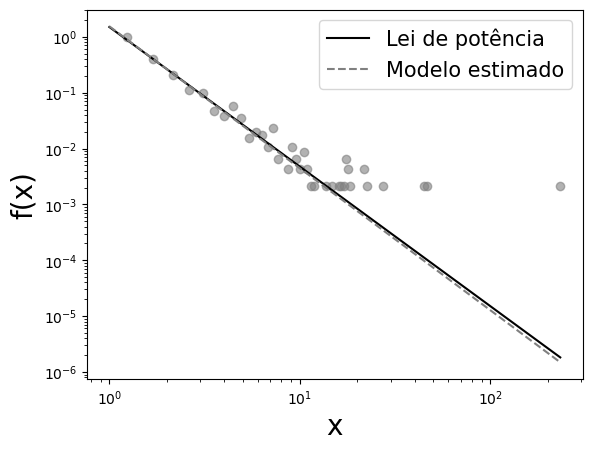

In [2]:
# Pág. 490
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

alpha = 2.5 # parâmetro do modelo lei de potência
xmin = 1 # valor mínimo para o qual a lei é observada
n = 1000 # número de valores gerados
data = [] # lista que armazena os valores
# gera a amostra
for i in range(0,n):
    # usa o método da transformada inversa
    u = np.random.uniform(0,1)
    x = xmin*(1 - u)**(-1/(alpha-1))
    data.append(x)

## mostra a distribuição dos dados gerados
nb = 500 # número de bins
p, bins = np.histogram(data, bins = nb, density=True)
bins_mean = [0.5 * (bins[i] + bins[i+1]) 
             for i in range(len(p))]
plt.loglog(bins_mean, p, 'o',
           color = 'gray', alpha=0.6)

# mostra a curva teórica
y = np.linspace(1, np.max(data), 100)
f = (alpha-1)*xmin**(alpha-1)*y**(-alpha)
plt.plot(y,f,'-', color = 'black', 
         label = 'Lei de potência')

# estimação de máxima verossimilhança
s = 0
for i in range(0,n):
    s += np.log(data[i]/xmin)
alpha_hat = 1 + n/s
# modelo estimado
f_hat = (alpha_hat-1)*xmin**(alpha_hat-1)*y**(-alpha_hat)
plt.plot(y,f_hat,'--', color = 'gray', 
         label = 'Modelo estimado')
plt.xlabel('x', fontsize = 20)
plt.ylabel('f(x)',fontsize = 20)
plt.legend(fontsize = 15)
plt.show(True)

In [5]:
# Pág. 494
!pip install powerlaw
import powerlaw
import numpy as np
np.random.seed(42)

def generate_power_law(n, alpha,xmin):
    data = [] # lista que armazena os valores
    for i in range(0,n):
        # usa o método da transformada inversa
        u = np.random.uniform(0,1)
        x = xmin*(1 - u)**(-1/(alpha-1))
        data.append(x)
    return data

alpha = 2 
xmin = 1
n = 1000 # número de valores gerados
# gera a amostra
data = generate_power_law(n, alpha,xmin)

results = powerlaw.Fit(data)
print('alpha estimado:', results.power_law.alpha)
print('xmin estimado:', results.power_law.xmin)

Calculating best minimal value for power law fit


Fitting xmin: 100%|████████████████████████| 998/998 [00:00<00:00, 22854.25it/s]

alpha estimado: 2.009144540685758
xmin estimado: 1.164041670213111


In [18]:
# Pág. 495
import powerlaw
import pandas as pd
import numpy as np
np.random.seed(101)

cities = pd.read_csv('data/BRAZIL_CITIES_REV2022.csv', header=0)
cities = cities.dropna(axis='rows') #remove NaN
data = cities['IBGE_RES_POP']
data = np.array(data)
n = len(data)

results = powerlaw.Fit(data,discrete=True)
xmin = results.power_law.xmin
alpha_hat = results.power_law.alpha
print('alpha estimado:', alpha_hat)
print('xmin estimado:', xmin)

/opt/anaconda3/lib/python3.13/site-packages/powerlaw/fitting.py:264: UserWarning: Values less than or equal to 0 in data. Throwing out 0 or negative values.
  warnings.warn("Values less than or equal to 0 in data. Throwing out 0 or negative values.")


Calculating best minimal value for power law fit


Fitting xmin: 100%|███████████████████████| 5041/5041 [00:01<00:00, 3818.59it/s]

alpha estimado: 2.1353608562065522
xmin estimado: 22151.0
